In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from collections import namedtuple
import plotly.graph_objects as go

In [2]:
# --- Define parameter structure ---
ParamSet = namedtuple('ParamSet', [
    'T', 'alpha', 'Pa',
    'cTub', 'ha', 'pEf', 'pDist', 'fHenEq', 'fReab',
    'rHen', 'rAffEq',  'par_rEff', 'omega', 'd', 'beta',
    'psiMin', 'psiMax', 'psiEq',
    'cAff', 'a', 'b'
])

# --- Base parameters (modifiable copy per run) ---
base_params = ParamSet(
    T=11.5,          # Henle's loop delay etc. [s]
    alpha=20,        # TGF strengs, Test and task 2.1
    Pa=13.0,         # Arterial blood preasure [kPa],  1kPa = 7.5mmHg
    cTub=3.0,        # Elasticity [nL/kPa]
    ha=0.5,          # Arterial hematochrite
    pEf=1.3,         # Efferent arterial pressure [kPa]
    pDist=0.6,       # Distal tubulus hydrostatic pressure [kPa]
    fHenEq=0.2,      # Henle's loop equilibrium flow [nL/s]
    fReab=0.3,       # Proximate tubulus reabsorption flow [nL/s]
    rHen=5.3,        # Henle's loop resistance [kPa*s/nL]
    rAffEq=2.4,      # Afferent arteriole equilibrium resistance [kPa*s/nL]
    par_rEff=1.9,    # Efferent arterial resistance [kPa*s/nL]%
    omega=20.0,      # Damped oscillator parameter [kPa*s^2]
    d=0.04,          # Damped oscillator parameter [1/s]
    beta=0.67,       # Non-variable fraction of efferent arteriole
    psiMin=0.20,     # Lower activation limit
    psiMax=0.44,     # Upper activation limit
    psiEq=0.38,      # Equilibrium activation

    cAff=54.0,       # Afferent plasma protein concentration [g/L]
    a=21.7e-3,       # Protein concentration parameter [kPa*L/g]
    b=0.39e-3        # Protein concentration parameter [kPa*L^2/g^2]
)

# --- Initial Conditions ---
state_init = [2.07828, 1.1891, -0.186993, 1.44853, 1.25917, 1.0752, 0]
varnames = 'Pt', 'r', 'rdot', 'X1', 'X2', 'X3', 'FFilt_mem'

In [3]:
# --- Model Function --- Translated to Python by ChatGPT from Olga's MATLAB code.
def model(t, state, p):
    Pt, r, rdot, X1, X2, X3, FFilt_mem = state

    FHen = (Pt - p.pDist) / p.rHen
    Ra = p.rAffEq * (p.beta + (1 - p.beta) / r**4)
    R = p.rAffEq / Ra

    A = p.b + R * p.b * p.ha
    B = p.a + R * p.b * p.cAff * (1 - p.ha) + R * p.a * p.ha
    C = Pt - p.pEf + R * p.a * p.cAff * (1 - p.ha) + R * (Pt - p.Pa) * p.ha
    D = (Pt - p.Pa) * R * p.cAff * (1 - p.ha)

    roots = np.roots([A, B, C, D])
    Ce = next((r.real for r in roots if np.isreal(r) and r.real >= 0), 0)

    Pg = p.b * Ce**2 + p.a * Ce + Pt
    Pav = (p.Pa - (p.Pa - Pg) * p.beta * p.rAffEq / Ra + Pg) / 2
    FFilt = (1 - p.ha) * (1 - p.cAff / Ce) * ((p.Pa - Pg) / Ra)

    Pel = 1.6 * (r - 1) + 2.4 * np.exp(10 * (r - 1.4))
    Pact = 6.3 + 7.2 * r + 4.7 / (1 + np.exp(13 * (0.4 - r)))

    Psi = p.psiMax - (p.psiMax - p.psiMin) / (
        1 + (p.psiEq - p.psiMin) / (p.psiMax - p.psiEq) *
        np.exp(p.alpha * (3 * X3 / p.T / p.fHenEq - 1))
    )
    Peq = Pel + Psi * Pact

    # Derivatives
    dPtdt = (FFilt - p.fReab - FHen) / p.cTub
    drdt = rdot
    drdotdt = (Pav - Peq) / p.omega - p.d * rdot
    dX1dt = FHen - 3 / p.T * X1
    dX2dt = 3 / p.T * (X1 - X2)
    dX3dt = 3 / p.T * (X2 - X3)
    dFFiltdt = FFilt - FFilt_mem

    return dPtdt, drdt, drdotdt, dX1dt, dX2dt, dX3dt, dFFiltdt

In [4]:
# --- Time Setup ---
t_start, t_end = 0, 3000
n = 10000
t_eval = np.linspace(2500, t_end, n)

## Test run

In [5]:
solution = solve_ivp(model, (t_start, t_end), state_init, args=(base_params,), t_eval=t_eval)

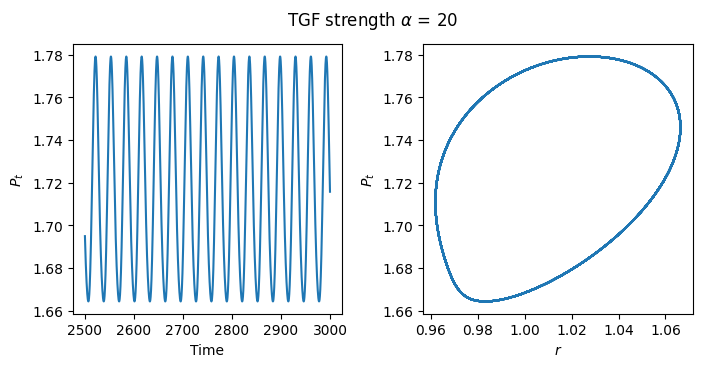

In [6]:
f, (ax,ax1) = plt.subplots(1,2, figsize=(8,3.5))
plt.subplots_adjust(wspace=0.3)
ax.plot(solution.t, solution.y[0])
ax.set_xlabel('Time')
ax.set_ylabel('$P_t$')

ax1.plot(solution.y[1], solution.y[0])
ax1.set_ylabel('$P_t$')
ax1.set_xlabel('$r$')

plt.suptitle("TGF strength " + r"$\alpha$ = " + f"{base_params.alpha}");

## Task 1 (part 1 - chaos)

In [7]:
p = base_params._replace(alpha=37)

In [8]:
solution = solve_ivp(model, (t_start, t_end), state_init, args=(p,), t_eval=t_eval)

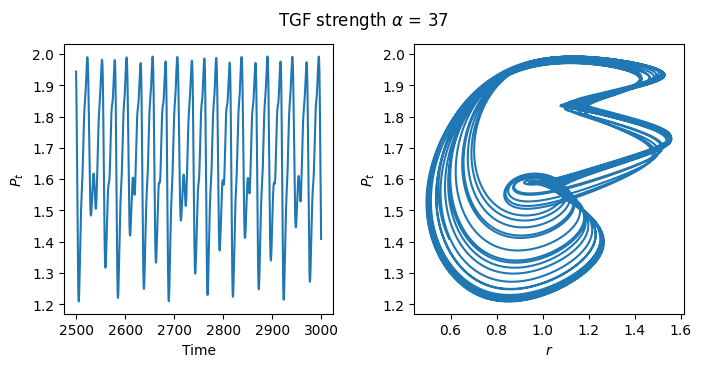

In [9]:
f, (ax,ax1) = plt.subplots(1,2, figsize=(8,3.5))
plt.subplots_adjust(wspace=0.3)
ax.plot(solution.t, solution.y[0])
ax.set_xlabel('Time')
ax.set_ylabel('$P_t$')

ax1.plot(solution.y[1], solution.y[0])
ax1.set_ylabel('$P_t$')
ax1.set_xlabel('$r$')

plt.suptitle("TGF strength " + r"$\alpha$ = " + f"{p.alpha}");

## Task 1 (part 2 - Period on Henle's loop delay T)

In [10]:
from scipy.signal import find_peaks

In [11]:
Ts = np.arange(9,15.5,.5)

periods = []

for T_val in Ts:
    p = base_params._replace(T=T_val)
    solution = solve_ivp(model, (t_start, t_end), state_init, args=(p,), t_eval=t_eval)

    pt_vec = solution.y[0]

    pks, _ = find_peaks(pt_vec, prominence=0.01)
    peak_times = solution.t[pks]

    # ### Check that peaks are found correctly!
    # plt.figure()
    # plt.plot(solution.t, pt_vec)
    # plt.plot(peak_times, pt_vec[pks], '.')

    periods.append(np.diff(peak_times).mean())


Text(0, 0.5, 'Pt oscillation period')

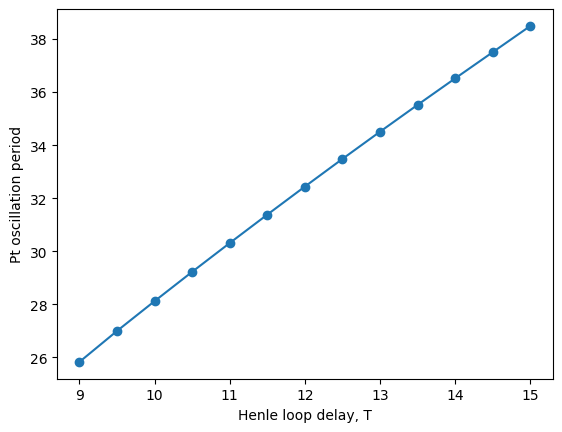

In [12]:
plt.plot(Ts, periods, 'o-')
plt.xlabel('Henle loop delay, T')
plt.ylabel('Pt oscillation period')

## Task 2 part 1: How arterial pressure Pa influences tubular pressure oscillations, Pt

In [18]:
# from mpl_toolkits.mplot3d import Axes3D # Not needed for google colab
# %matplotlib widget

In [5]:
t_eval = np.linspace(2800, t_end, n)

In [17]:
#p.alpha, p.T

(12, 11.5)

In [18]:
Pas = np.arange(11, 14, 0.2)
pt_solutions = np.zeros((Pas.size, t_eval.size))
r_solutions = np.zeros((Pas.size, t_eval.size))

for i, Pa_val in enumerate(Pas):
    p = base_params._replace(Pa=Pa_val)
    solution = solve_ivp(model, (t_start, t_end), state_init, args=(p,), t_eval=t_eval)

    pt_solutions[i] = solution.y[0]
    r_solutions[i] = solution.y[1]

tvec = solution.t

Text(0.5, 0, 'Pt')

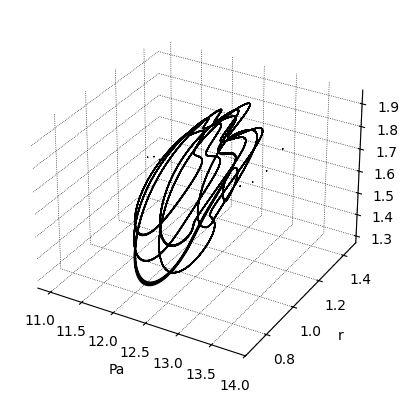

In [20]:
fig = plt.figure()
ax = plt.axes(projection='3d')

for Pa, pt_vec, r_vec in zip(Pas, pt_solutions, r_solutions):
    pas = np.ones(tvec.size)*Pa
    ax.plot3D(pas, r_vec, pt_vec, color='k', alpha=1, lw=1)

# === Remove gray pane shading ===
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))  # Transparent
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

kw = dict(color='k', linewidth=0.5, linestyle=':')

ax.xaxis._axinfo['grid'].update(kw)
ax.yaxis._axinfo['grid'].update(kw)
ax.zaxis._axinfo['grid'].update(kw)

ax.set_xlabel('Pa')
ax.set_ylabel('r')
ax.set_zlabel('Pt')

In [21]:
fig = go.Figure()


t_skip = 1

for Pa, pt_vec, r_vec in zip(Pas, pt_solutions, r_solutions):
    pas = np.ones(tvec.size)*Pa

    fig.add_trace(go.Scatter3d(
        x=pas[::t_skip],
        y=pt_vec[::t_skip],
        z=r_vec[::t_skip],
        mode='lines',
        line=dict(
            color=(0,0,0,1), # (R G B Alpha)
            width=5,
        ), showlegend=False
    ))


# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='Pa',
        yaxis_title='Pt',
        zaxis_title='r',
        xaxis=dict(showline=True, linecolor='black'),
        yaxis=dict(showline=True, linecolor='black'),
        zaxis=dict(showline=True, linecolor='black'),
        aspectratio=dict(x=1, y=1, z=0.7)
    ),
    title='Effect of F on oscillation',
    width=800,
    height=700
)

# Set the camera view
fig.update_layout(scene_camera=dict(
    eye=dict(x=1.35, y=-1.35, z=1.35)  # controls the camera position
))

Output hidden; open in https://colab.research.google.com to view.

## Task 2, part 2 & 3 : myogenic response and how Ffilt changes with Pa

Set alpha to 12 - at each loop iteration

In [12]:
Pas = np.arange(8, 15, 0.2)
ffilt_solutions = np.zeros((Pas.size, t_eval.size))
r_solutions = np.zeros((Pas.size, t_eval.size))

for i, Pa_val in enumerate(Pas):
    p = base_params._replace(Pa=Pa_val, alpha=12)
    solution = solve_ivp(model, (t_start, t_end), state_init, args=(p,), t_eval=t_eval)

    ffilt_solutions[i] = solution.y[-1]
    r_solutions[i] = solution.y[1]

tvec = solution.t

Text(0.5, 0, 'Ffilt')

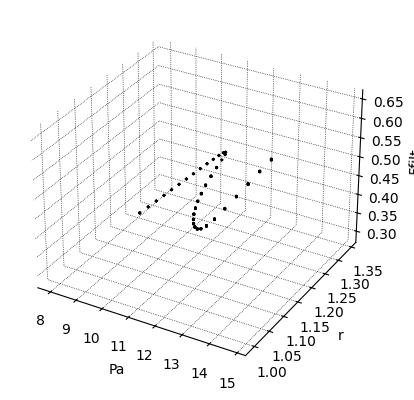

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for Pa, ffilt_vec, r_vec in zip(Pas, ffilt_solutions, r_solutions):
    pas = np.ones(tvec.size)*Pa
    ax.plot3D(pas, r_vec, ffilt_vec, color='k', alpha=1, lw=2)

# === Remove gray pane shading ===
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))  # Transparent
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

kw = dict(color='k', linewidth=0.5, linestyle=':')

ax.xaxis._axinfo['grid'].update(kw)
ax.yaxis._axinfo['grid'].update(kw)
ax.zaxis._axinfo['grid'].update(kw)

ax.set_xlabel('Pa')
ax.set_ylabel('r')
ax.set_zlabel('Ffilt')

In [16]:
fig = go.Figure()

for Pa, ffilt_vec, r_vec in zip(Pas, ffilt_solutions, r_solutions):
    pas = np.ones(tvec.size)*Pa

    fig.add_trace(go.Scatter3d(
        x=pas,
        y=r_vec,
        z=ffilt_vec,
        mode='lines',
        line=dict(
            color=(0,0,0,1), # (R G B Alpha)
            width=5,
        ), showlegend=False
    ))


# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='Pa',
        yaxis_title='r',
        zaxis_title='Ffilt',
        xaxis=dict(showline=True, linecolor='black'),
        yaxis=dict(showline=True, linecolor='black'),
        zaxis=dict(showline=True, linecolor='black'),
        aspectratio=dict(x=1, y=1, z=0.7)
    ),
    title='Effect of F on oscillation',
    width=800,
    height=700
)

# Set the camera view
fig.update_layout(scene_camera=dict(
    eye=dict(x=1.35, y=-1.35, z=1.35)  # controls the camera position
))

Output hidden; open in https://colab.research.google.com to view.

Text(0.5, 0, 'Pa')

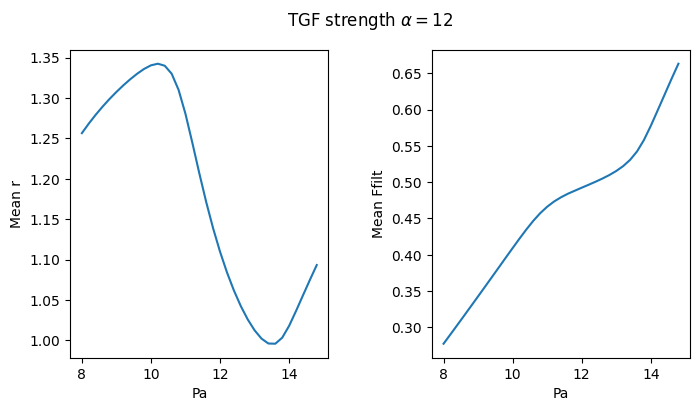

In [14]:
f, (ax,ax1) = plt.subplots(1,2, figsize=(8,4))
plt.subplots_adjust(wspace=0.4)
ax.plot(Pas, r_solutions.mean(axis=1))
ax.set_ylabel('Mean r')
ax.set_xlabel('Pa')
plt.suptitle('TGF strength ' + r'$\alpha = $' + f'{p.alpha}')

ax1.plot(Pas, ffilt_solutions.mean(axis=1))
ax1.set_ylabel('Mean Ffilt')
ax1.set_xlabel('Pa')